In [1]:
#======================================================================================================#
# Import Libraries
#======================================================================================================#
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ydata_profiling import ProfileReport

import sklearn
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,StandardScaler,PowerTransformer
from sklearn.model_selection import train_test_split,cross_val_score,RandomizedSearchCV,StratifiedKFold
from sklearn.feature_selection import SelectKBest,f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,roc_auc_score,auc,roc_curve

import joblib

In [2]:
#======================================================================================================#
# Load Dataset and Ingore all warnings
#======================================================================================================#
warnings.filterwarnings('ignore')
loan_df = pd.read_csv('loan_data.csv')
print("✅ Data Loading Complete!")

✅ Data Loading Complete!


In [3]:
#======================================================================================================#
# Dataset Overview
#======================================================================================================#
print("#" + "=" * 135 + "#")
display(loan_df.head())
print("#" + "=" * 135 + "#")
print(f"Dataset Shape: {loan_df.shape}")
print("#" + "=" * 135 + "#")
display(loan_df.info())
print("#" + "=" * 135 + "#")
display(loan_df.describe())
print("#" + "=" * 135 + "#")
display(loan_df.select_dtypes(include = ['number']).corr())
print("#" + "=" * 135 + "#")
display(loan_df.select_dtypes(include = ['number']).skew())
print("#" + "=" * 135 + "#")
display(loan_df.select_dtypes(include = ['number']).cov())
print("#" + "=" * 135 + "#")
print("✅ Dataset Overview Complete!")

#=======================================================================================================================================#


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


#=======================================================================================================================================#
Dataset Shape: (45000, 14)
#=======================================================================================================================================#
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45

None

#=======================================================================================================================================#


...

#=======================================================================================================================================#


person_age                     2.548154
person_income                 34.137583
person_emp_exp                 2.594917
loan_amnt                      1.179731
loan_int_rate                  0.213784
loan_percent_income            1.034512
cb_person_cred_hist_length     1.631720
credit_score                  -0.610261
loan_status                    1.336351
dtype: float64

#=======================================================================================================================================#


,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
person_age,36.543333,9.416864e+04,34.983699,1.937322e+03,0.241326,-0.022827,20.216311,54.402323,-0.053974
person_income,94168.637698,6.467778e+09,90695.590885,1.230492e+08,361.699121,-1642.474899,38788.385061,145694.779218,-4540.757866
person_emp_exp,34.983699,9.069559e+04,36.766421,1.707351e+03,0.300397,-0.021079,19.390738,56.942406,-0.051631
loan_amnt,1937.321762,1.230492e+08,1707.350980,3.987779e+07,2748.133115,326.592661,1052.743272,2890.129401,282.791227
loan_int_rate,0.241326,3.616991e+02,0.300397,2.748133e+03,8.873299,0.032528,0.208116,1.727408,0.411162
loan_percent_income,-0.022827,-1.642475e+03,-0.021079,3.265927e+02,0.032528,0.007606,-0.010783,-0.050510,0.013955
cb_person_cred_hist_length,20.216311,3.878839e+04,19.390738,1.052743e+03,0.208116,-0.010783,15.052086,30.369742,-0.023954
credit_score,54.402323,1.456948e+05,56.942406,2.890129e+03,1.727408,-0.050510,30.369742,2543.776478,-0.160349
loan_status,-0.053974,-4.540758e+03,-0.051631,2.827912e+02,0.411162,0.013955,-0.023954,-0.160349,0.172843


#=======================================================================================================================================#
✅ Dataset Overview Complete!


## Exploratory Data Analysis & Observations

### 1. Demographics (`person_age` & `person_emp_exp`)
* **`person_age`**: The data is heavily **right-skewed** with a low overall spread. A significant majority of applicants fall within the **21.72 to 33.81** age range. However, the column contains a critical data quality issue with an impossible maximum outlier of **144 years**.
* **`person_emp_exp`**: This column is also strongly **right-skewed** with a low spread. Most applicants have work experience ranging from **0 to 11.47 years**. It contains an impossible extreme outlier of **125 years** of experience.

### 2. Financial Profile (`person_income` & `credit_score`)
* **`person_income`**: The distribution is highly **right-skewed** with a very high spread. While the 75th percentile sits at **$95,789.25**, the column is heavily distorted by extreme upper outliers, reaching a maximum income of **$7,200,766.00**. 
* **`credit_score`**: Unlike other features, this data is **left-skewed**. It has a **low spread** (Standard Deviation of ~50), meaning most applicant scores are tightly clustered between **582.17 and 683.04**, representing a predominantly average-to-low credit tier.

### 3. Loan Details (`loan_amnt`, `loan_int_rate`, `loan_percent_income`)
* **`loan_amnt`**: The distribution is **right-skewed** with a medium spread. Most requested loan amounts range between **$3,268.27 and $15,898.04**, featuring several natural high-value outliers up to **$35,000.00**.
* **`loan_int_rate`**: This is the only feature that follows an approximately **normal distribution**. It has a low spread, with most interest rates safely concentrated between **8.03% and 13.99%**.
* **`loan_percent_income`**: The data is **right-skewed** with a low spread. For the majority of applicants, the loan amount accounts for **5.25% to 22.69%** of their total income.

### 4. Credit History & Target Variable (`cb_person_cred_hist_length` & `loan_status`)
* **`cb_person_cred_hist_length`**: The feature is **right-skewed** with a low spread. The typical credit history length for most individuals is between **1.99 and 9.75 years**.
* **`loan_status` (Target)**: This is a binary categorical variable. The dataset has a mean of **0.2222**, which indicates a **22.22% loan default rate** (Status = 1) and a **77.78% non-default rate** (Status = 0).


# ***Data Cleaning***

In [4]:
print("#" + "=" * 135 + "#")
print(f"How Many Null Values Present In Dataset: {loan_df.isnull().sum()}")
print("#" + "=" * 135 + "#")
print(f"How Many Duplicates Values Present In Dataset: {loan_df.duplicated().sum()}")
print("#" + "=" * 135 + "#")
print(f"How Many Unique Values Present In Dataset: {loan_df.nunique()}")

# Drop Inconsiste Data 
loan_df = loan_df[loan_df['person_age'] < 65]

# Convert All Object Columns in Lower-case
object_columns = loan_df.select_dtypes(include = ['object']).columns
loan_df[object_columns] = loan_df[object_columns].apply(lambda x:x.str.lower())

# Change the DataType
numeric_columns = loan_df[['person_age','cb_person_cred_hist_length']]
for num_cols in numeric_columns:
    loan_df[num_cols] = loan_df[num_cols].astype('int32')
categorical_columns = loan_df.select_dtypes(include = ['object']).columns
loan_df[categorical_columns] = loan_df[categorical_columns].apply(lambda x:x.astype('category'))

# Binning
age_bins = [17,25,35,45,60,65]
age_labels = ['18-25','26-35','36-45','46-60','60+']
loan_df['person_age_category'] = pd.cut(loan_df['person_age'],bins = age_bins,labels = age_labels)
credit_bins = [200,400,600,800]
credit_labels = ['low','moderate','high']
loan_df['credit_score_category'] = pd.cut(loan_df['credit_score'],bins = credit_bins,labels = credit_labels)

print("✅ Data Cleaning Complete!")


#=======================================================================================================================================#
How Many Null Values Present In Dataset: person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64
#=======================================================================================================================================#
How Many Duplicates Values Present In Dataset: 0
#====================================================================================================================

# ***Exploratory Data Analysis***

#==================================================#
person_age Has 2139 outliers


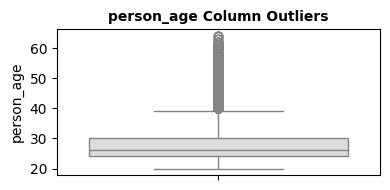

#==================================================#
person_income Has 2211 outliers


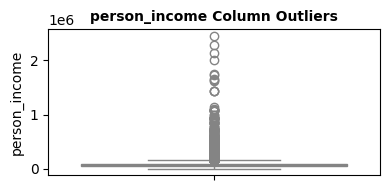

#==================================================#
person_emp_exp Has 1675 outliers


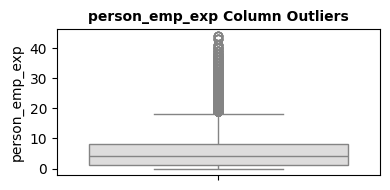

#==================================================#
loan_amnt Has 2342 outliers


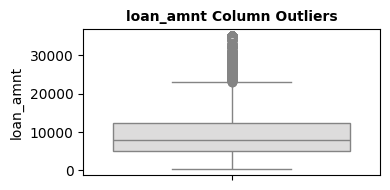

#==================================================#
loan_int_rate Has 124 outliers


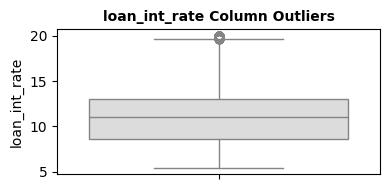

#==================================================#
loan_percent_income Has 741 outliers


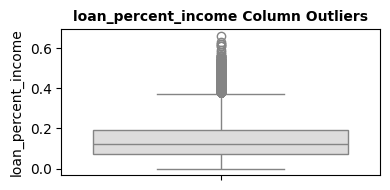

#==================================================#
cb_person_cred_hist_length Has 1321 outliers


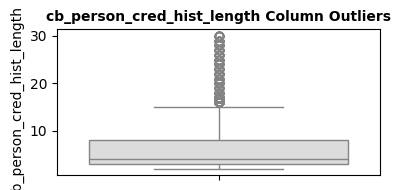

#==================================================#
credit_score Has 460 outliers


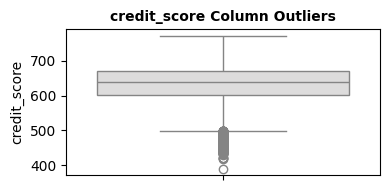

#=================================================================#
Total Dataset Percentage Outliers Is: 16.47%
#=================================================================#
Total Unique Outliers Present In Dataset: 7402
#=================================================================#
✅ Outliers Detection Complete!


In [5]:
#======================================================================================================#
# Outliers Detection
#======================================================================================================#
outlier_data = loan_df.copy()
outlier_box = set()
numeric_column = [
    c for c in outlier_data.select_dtypes(include=['number']).columns 
    if 2 < outlier_data[c].nunique() < (len(outlier_data) * 0.95)
]
for num_col in numeric_column:
    Q1 = outlier_data[num_col].quantile(0.25)
    Q3 = outlier_data[num_col].quantile(0.75)
    IQR = Q3 - Q1
    Lower_round = Q1 - 1.5 * IQR
    Upper_round = Q3 + 1.5 * IQR

    outliers = outlier_data[(outlier_data[num_col] < Lower_round) | (outlier_data[num_col] > Upper_round)]
    outlier_box.update(outliers.index)
    print("#" + "=" * 50 + "#")
    print(f"{num_col} Has {len(outliers)} outliers")
    plt.figure(figsize=(4, 2))
    plt.title(f"{num_col} Column Outliers", fontsize=10, fontweight='bold')
    sns.boxplot(y=outlier_data[num_col], palette='coolwarm')
    plt.tight_layout()
    plt.show()
    plt.close()
    
total_per = (len(outlier_box) / len(outlier_data)) * 100
print("#" + "=" * 65 + "#")
print(f"Total Dataset Percentage Outliers Is: {total_per:.2f}%")
print("#" + "=" * 65 + "#")
print(f"Total Unique Outliers Present In Dataset: {len(outlier_box)}")
print("#" + "=" * 65 + "#")
print("✅ Outliers Detection Complete!")


#==================================================#
person_gender
male      24803
female    20148
Name: count, dtype: int64


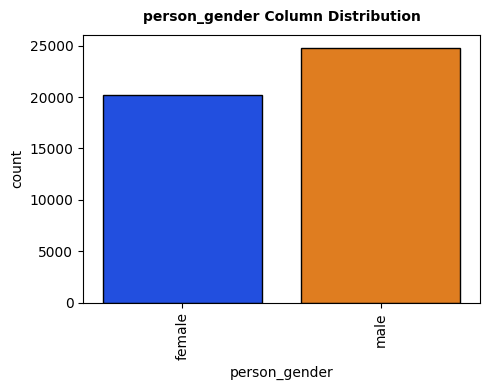

#==================================================#
person_education
bachelor       13383
associate      12014
high school    11955
master          6979
doctorate        620
Name: count, dtype: int64


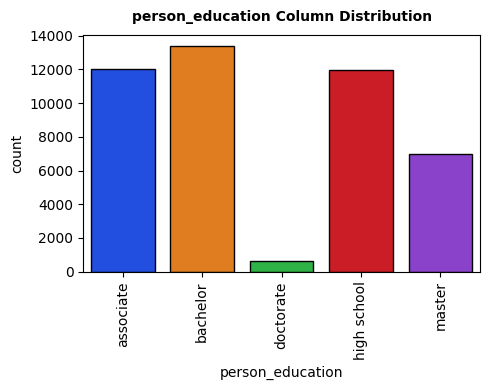

#==================================================#
person_home_ownership
rent        23409
mortgage    18474
own          2951
other         117
Name: count, dtype: int64


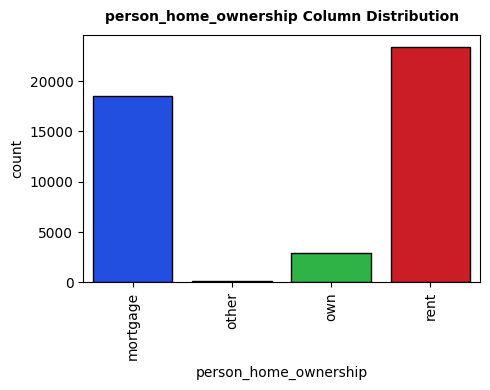

#==================================================#
loan_intent
education            9146
medical              8527
venture              7814
personal             7540
debtconsolidation    7142
homeimprovement      4782
Name: count, dtype: int64


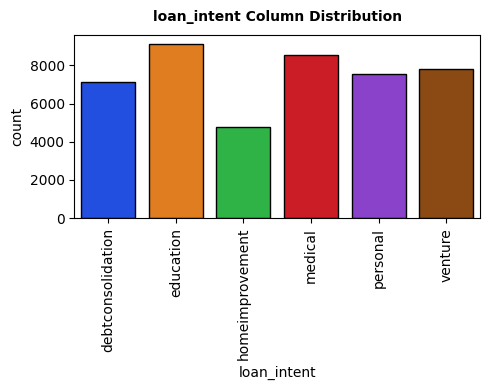

#==================================================#
previous_loan_defaults_on_file
yes    22845
no     22106
Name: count, dtype: int64


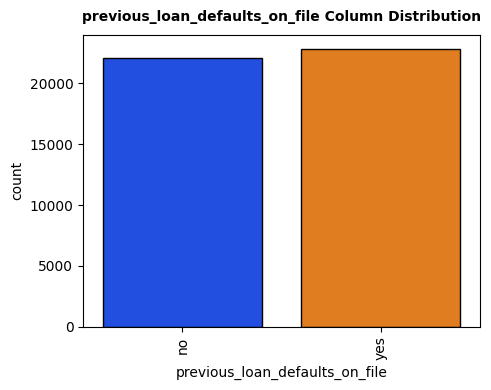

#==================================================#
person_age_category
18-25    20441
26-35    20073
36-45     3724
46-60      684
60+         29
Name: count, dtype: int64


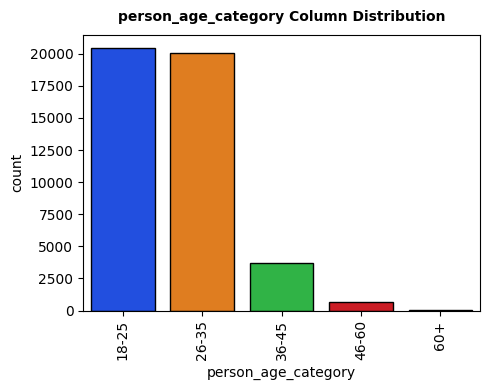

#==================================================#
credit_score_category
high        33903
moderate    11047
low             1
Name: count, dtype: int64


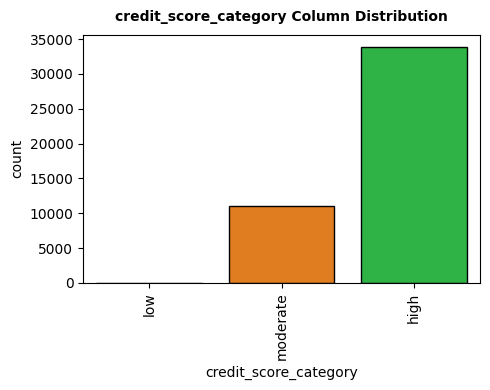

#==================================================#
credit_score_category
high        33903
moderate    11047
low             1
Name: count, dtype: int64


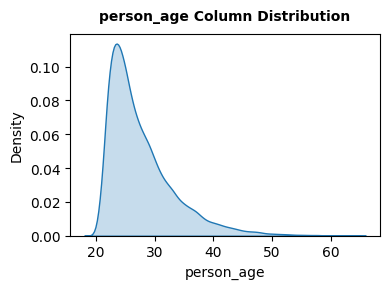

#==================================================#
credit_score_category
high        33903
moderate    11047
low             1
Name: count, dtype: int64


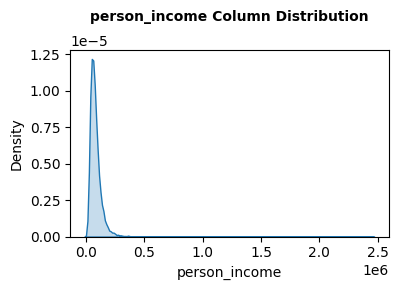

#==================================================#
credit_score_category
high        33903
moderate    11047
low             1
Name: count, dtype: int64


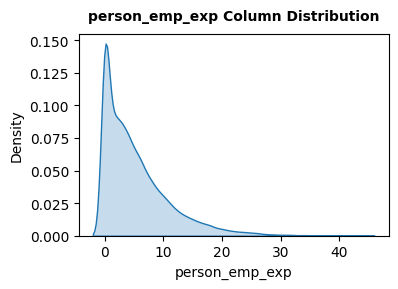

#==================================================#
credit_score_category
high        33903
moderate    11047
low             1
Name: count, dtype: int64


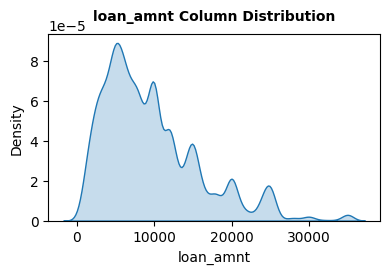

#==================================================#
credit_score_category
high        33903
moderate    11047
low             1
Name: count, dtype: int64


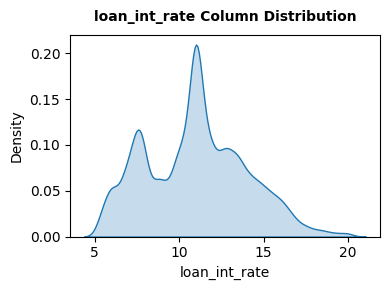

#==================================================#
credit_score_category
high        33903
moderate    11047
low             1
Name: count, dtype: int64


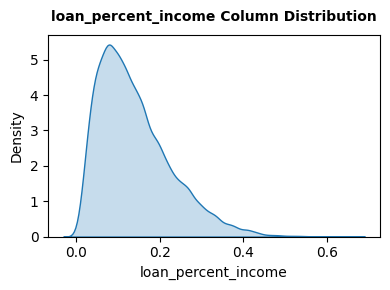

#==================================================#
credit_score_category
high        33903
moderate    11047
low             1
Name: count, dtype: int64


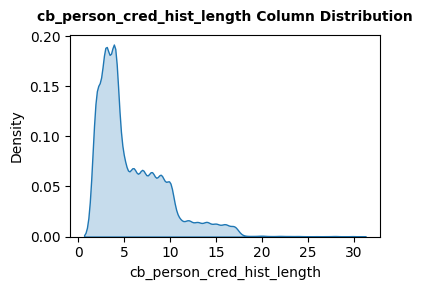

#==================================================#
credit_score_category
high        33903
moderate    11047
low             1
Name: count, dtype: int64


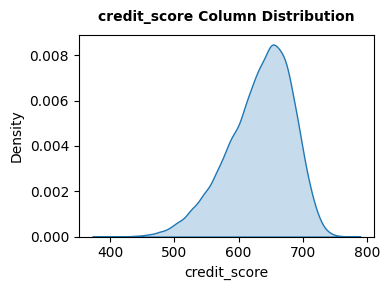

#==================================================#
credit_score_category
high        33903
moderate    11047
low             1
Name: count, dtype: int64


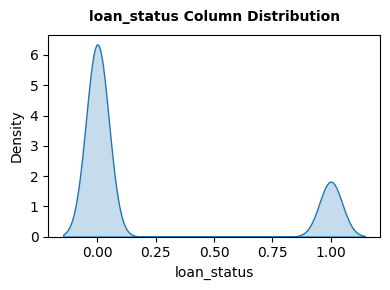

In [6]:
#======================================================================================================#
# All categorical columns Types and distribution
#======================================================================================================#
categorical_column = loan_df.select_dtypes(include = ['category']).columns
for cat_col in categorical_column:
    print("#" + "=" * 50 + "#")
    print(loan_df[cat_col].value_counts())
    plt.figure(figsize = (5,4))
    plt.title(f"{cat_col} Column Distribution",fontsize = 10,fontweight = 'bold',pad = 10)
    sns.countplot(data = loan_df,x = cat_col,palette = 'bright',edgecolor = 'black')
    plt.xticks(rotation = 'vertical')
    plt.tight_layout()
    plt.show()
    plt.close()
#======================================================================================================#
# All Numeric Columns distribution
#======================================================================================================#
numeric_column = loan_df.select_dtypes(include = ['number']).columns
for num_col in numeric_column:
    print("#" + "=" * 50 + "#")
    print(loan_df[cat_col].value_counts())
    plt.figure(figsize = (4,3))
    plt.title(f"{num_col} Column Distribution",fontsize = 10,fontweight = 'bold',pad = 10)
    sns.kdeplot(data = loan_df,x = num_col,fill = True)
    plt.tight_layout()
    plt.show()
    plt.close()


 SUMMARY FOR: PERSON AGE 


mean            min     max    
loan_status            0          1   0   1   0   1
person_gender                                      
female         27.675667  27.416555  20  20  64  63
male           27.850982  27.549728  20  20  64  64


Visualizing Distribution:


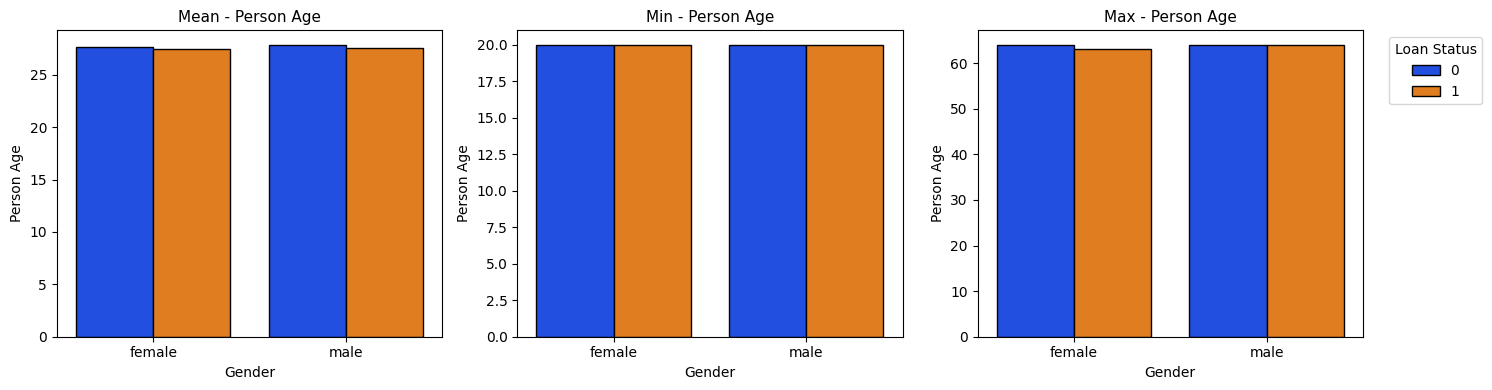


 SUMMARY FOR: PERSON INCOME 


mean                   min                max          
loan_status               0             1       0       1          0         1
person_gender                                                                 
female         84734.176050  59248.646363  9850.0  8000.0  2280980.0  778515.0
male           86362.551962  60379.966243  9595.0  8000.0  2448661.0  845636.0


Visualizing Distribution:


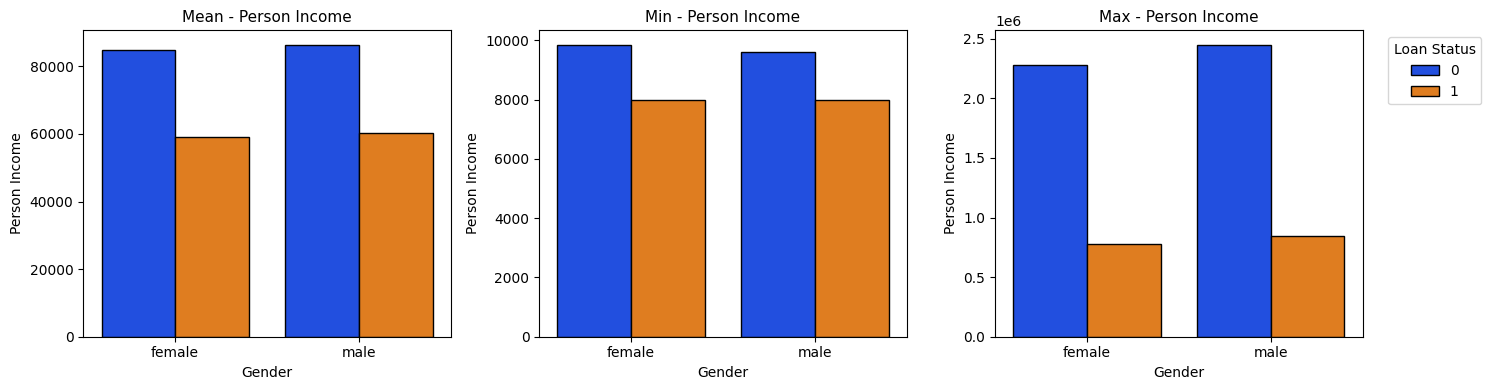


 SUMMARY FOR: PERSON EMP EXP 


mean           min    max    
loan_status           0         1   0  1   0   1
person_gender                                   
female         5.339461  5.072289   0  0  41  43
male           5.476650  5.207441   0  0  44  44


Visualizing Distribution:


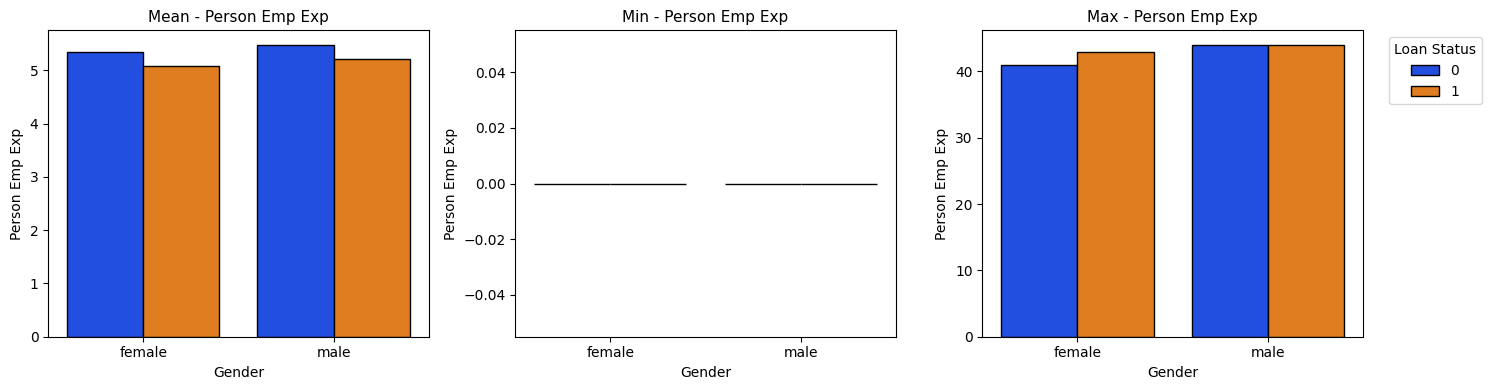


 SUMMARY FOR: LOAN AMNT 


mean                  min              max         
loan_status              0             1      0       1        0        1
person_gender                                                            
female         9129.204775  10820.788487  500.0   900.0  35000.0  35000.0
male           9292.210957  10870.748457  500.0  1000.0  35000.0  35000.0


Visualizing Distribution:


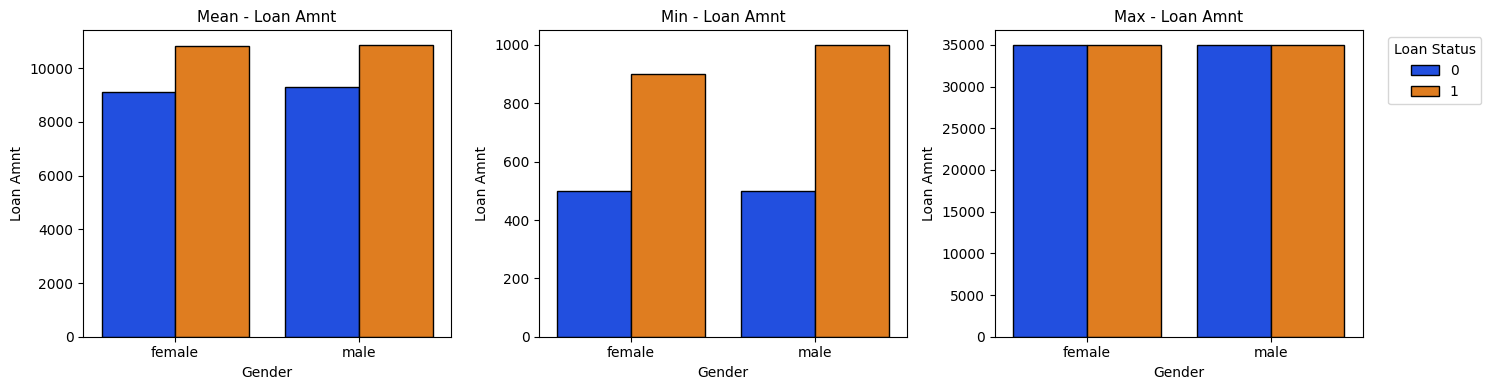


 SUMMARY FOR: LOAN INT RATE 


mean              min         max      
loan_status            0          1     0     1     0     1
person_gender                                              
female         10.469561  12.829996  5.42  5.42  20.0  20.0
male           10.483826  12.879338  5.42  5.42  20.0  20.0


Visualizing Distribution:


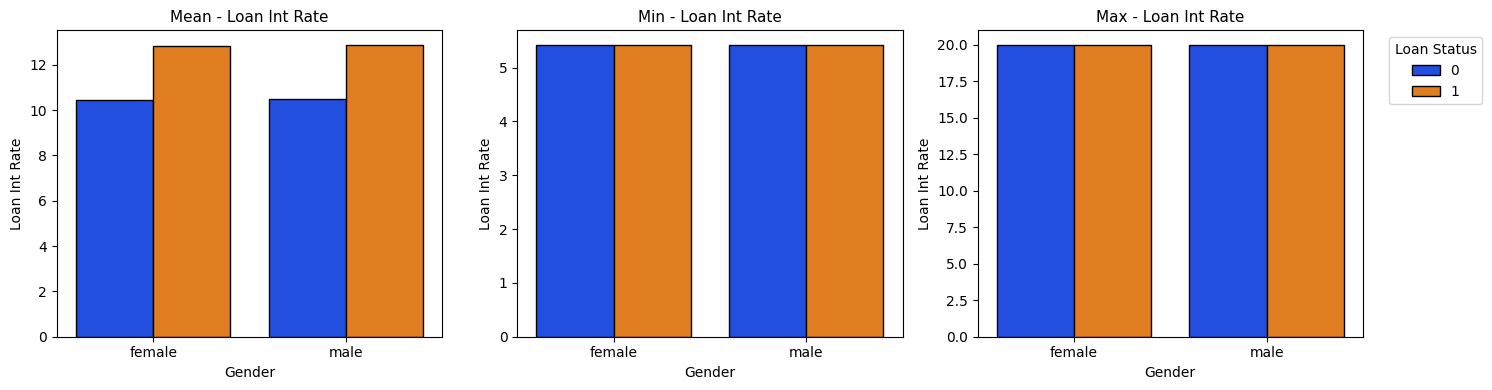


 SUMMARY FOR: LOAN PERCENT INCOME 


mean            min         max      
loan_status           0         1    0     1     0     1
person_gender                                           
female         0.121863  0.202120  0.0  0.00  0.66  0.61
male           0.121714  0.202764  0.0  0.01  0.56  0.62


Visualizing Distribution:


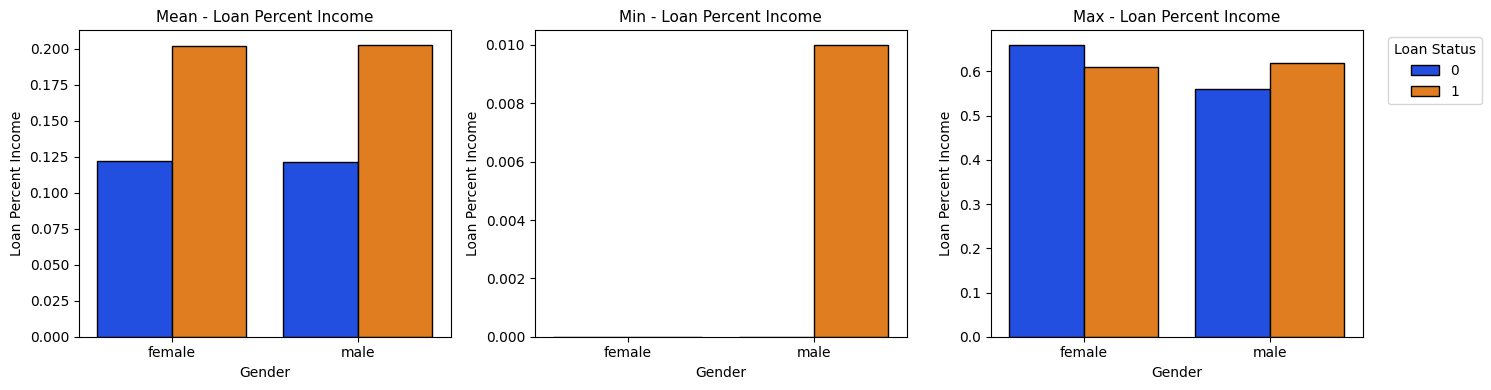


 SUMMARY FOR: CB PERSON CRED HIST LENGTH 


mean           min    max    
loan_status           0         1   0  1   0   1
person_gender                                   
female         5.835887  5.704373   2  2  30  30
male           5.914373  5.775862   2  2  30  30


Visualizing Distribution:


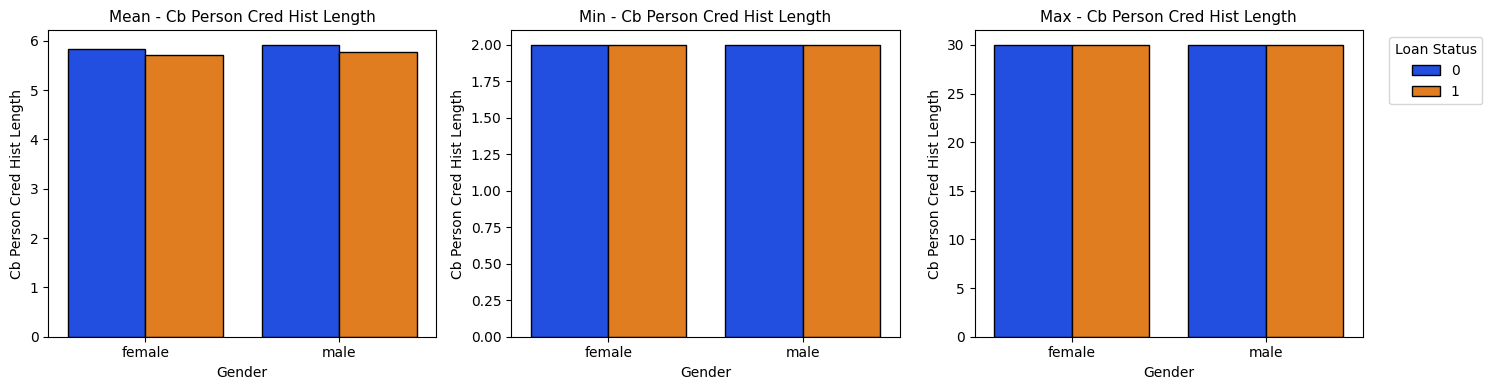


 SUMMARY FOR: CREDIT SCORE 


mean              min       max     
loan_status             0           1    0    1    0    1
person_gender                                            
female         632.925571  631.312807  419  431  765  767
male           632.538434  632.261525  390  437  772  755


Visualizing Distribution:


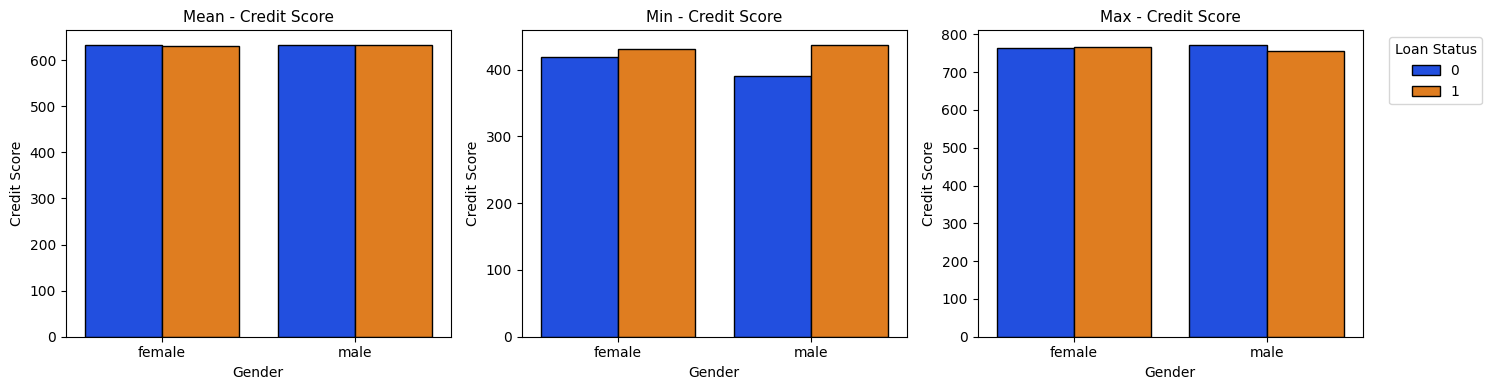

In [7]:
columns_to_plot = [
    'person_age', 'person_income', 'person_emp_exp', 'loan_amnt',
    'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score'
]
aggfun = ['mean', 'min', 'max']
for col in columns_to_plot:
    clean_title = col.replace('_', ' ').title()
    print(f"\n{'='*40}\n SUMMARY FOR: {clean_title.upper()} \n{'='*40}")
    pivot_summary = pd.pivot_table(
        loan_df,
        index='person_gender',
        columns='loan_status',
        values=col,
        aggfunc=aggfun
    )
    display(pivot_summary)
    print("\nVisualizing Distribution:")
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    for i, agg in enumerate(aggfun):
        sns.barplot(
            data=loan_df,
            x='person_gender',
            y=col,
            hue='loan_status',
            estimator=agg,
            palette='bright',
            edgecolor='black',
            errorbar=None,
            ax=axes[i]
        )
        axes[i].set_title(f"{agg.capitalize()} - {clean_title}", fontsize=11)
        axes[i].set_xlabel('Gender', fontsize=10)
        axes[i].set_ylabel(clean_title, fontsize=10)
        if i != len(aggfun) - 1:
            axes[i].get_legend().remove()
        else:
            axes[i].legend(title='Loan Status', bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()
    plt.close()


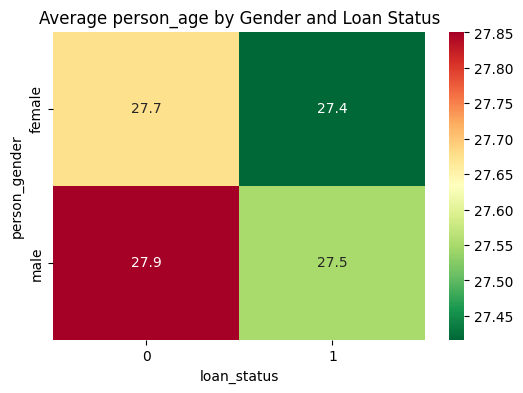

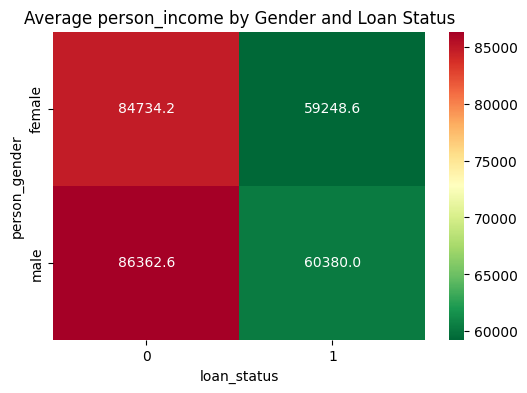

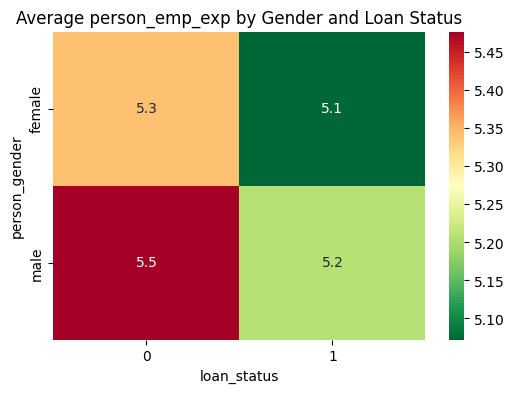

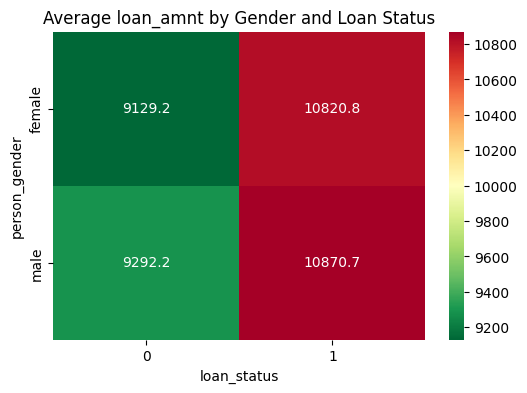

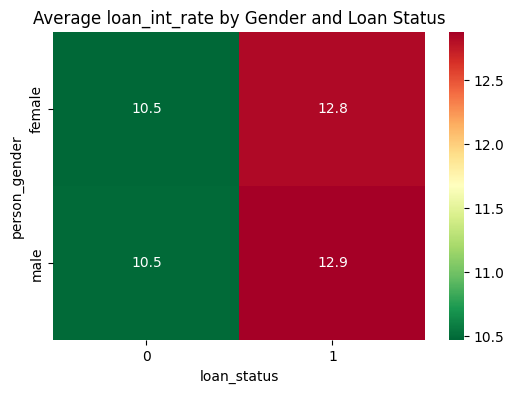

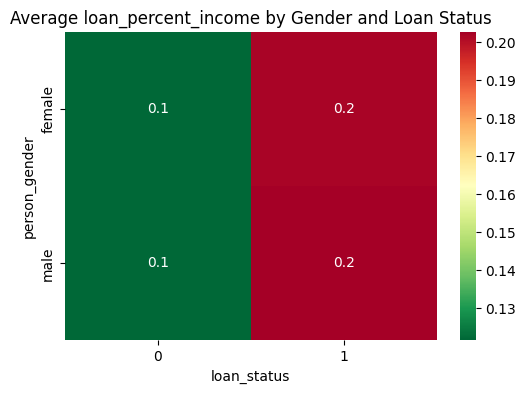

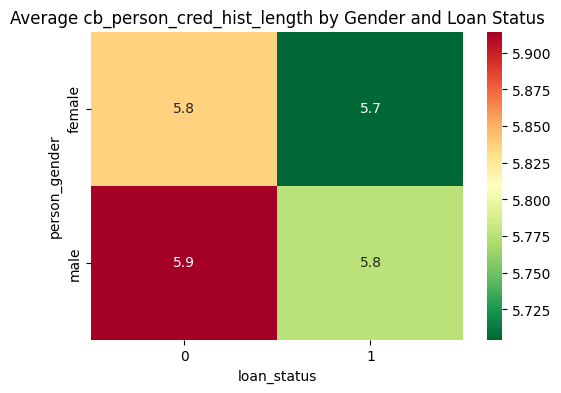

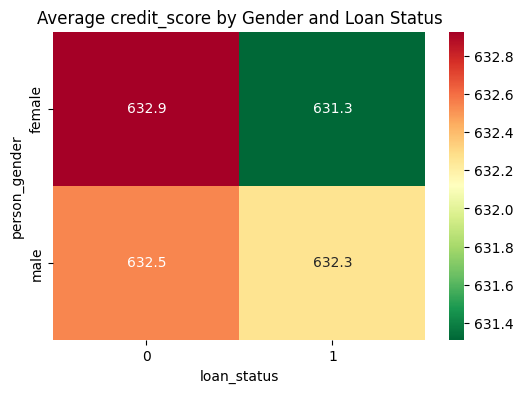

In [8]:
numeric_cols = ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score']
for cols in loan_df[numeric_cols]:
    c = pd.crosstab(index=loan_df['person_gender'], 
                    columns=loan_df['loan_status'], 
                    values=loan_df[cols], 
                    aggfunc='mean'
                   )
    plt.figure(figsize=(6, 4))
    plt.title(f'Average {cols} by Gender and Loan Status')
    sns.heatmap(c, annot=True, cmap='RdYlGn_r', fmt='.1f')
    plt.savefig(f'heatmap_{cols.replace(" ", "_")}.png')
    plt.show()
    plt.close()

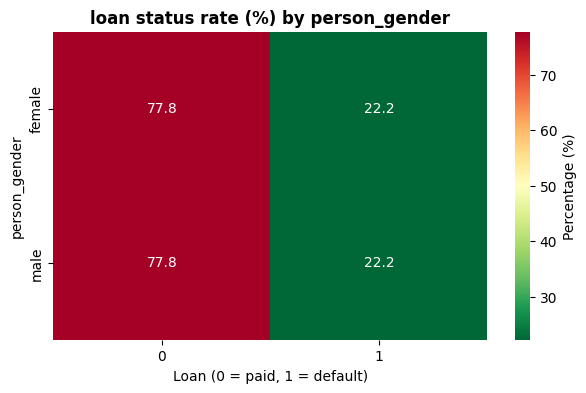

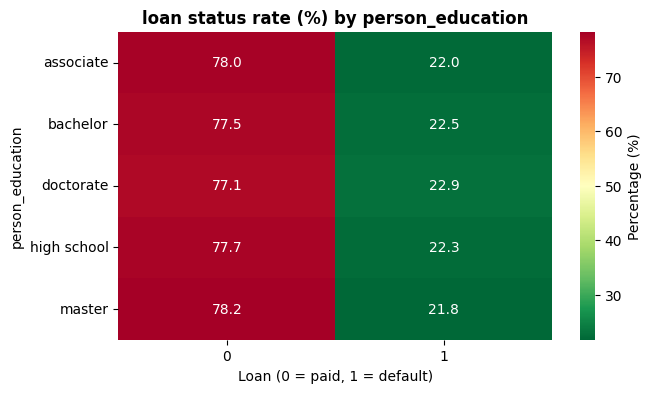

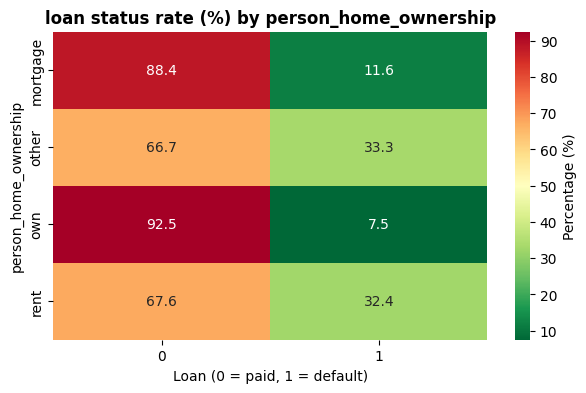

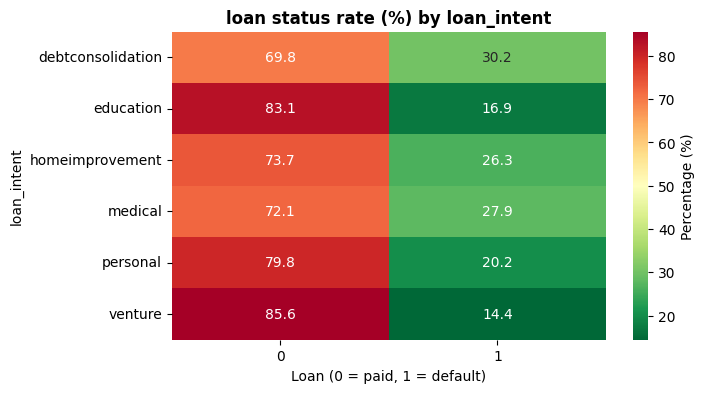

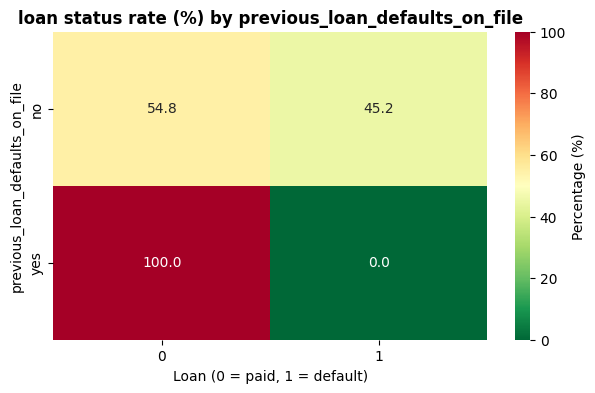

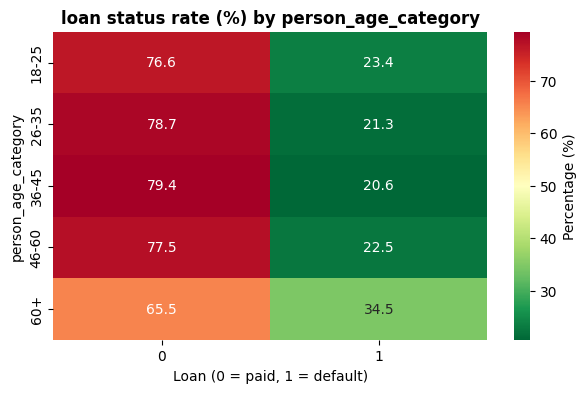

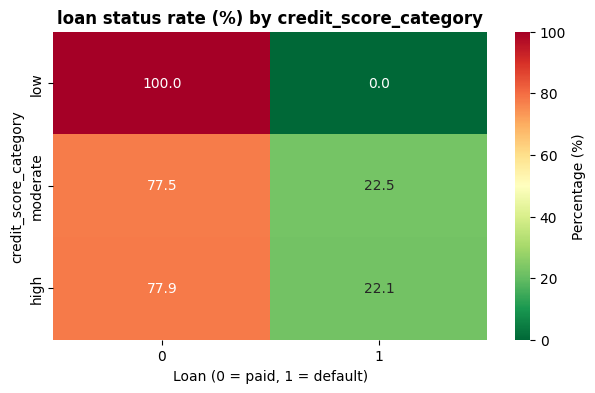

In [9]:
categorical_cols = ['person_gender', 'person_education', 'person_home_ownership',
       'loan_intent', 'previous_loan_defaults_on_file', 'person_age_category',
       'credit_score_category']
for col in categorical_cols:
    c_percentage = pd.crosstab(loan_df[col], loan_df['loan_status'], normalize='index') * 100
    plt.figure(figsize=(7, 4))
    plt.title(f'loan status rate (%) by {col}', fontsize=12, fontweight='bold')
    sns.heatmap(c_percentage, annot=True, cmap='RdYlGn_r', fmt='.1f', cbar_kws={'label': 'Percentage (%)'})
    plt.xlabel('Loan (0 = paid, 1 = default)')
    plt.ylabel(col)
    plt.savefig(f'loan_rate_{col.replace(" ", "_")}.png', bbox_inches='tight')
    plt.show()
    plt.close()

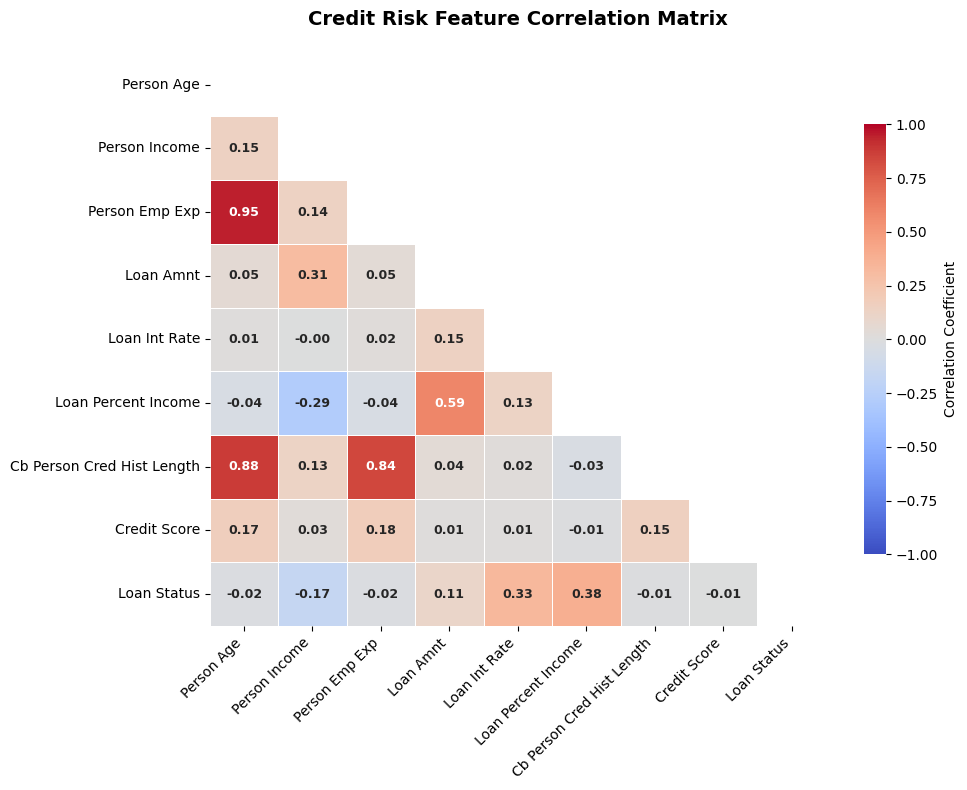

In [10]:
numeric_cols = [
    'person_age', 'person_income', 'person_emp_exp', 'loan_amnt',
    'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 
    'credit_score', 'loan_status' 
]
corr_matrix = loan_df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
plt.figure(figsize=(10, 8), dpi=100)
clean_labels = [col.replace('_', ' ').title() for col in numeric_cols]
sns.heatmap(
    corr_matrix, 
    mask=mask,                  
    annot=True,               
    fmt=".2f",                  
    cmap='coolwarm',          
    vmin=-1, vmax=1,          
    annot_kws={"size": 9, "weight": "bold"}, 
    linewidths=0.5,             
    cbar_kws={"shrink": 0.75, "label": "Correlation Coefficient"}
)

plt.title('Credit Risk Feature Correlation Matrix', fontsize=14, pad=20, weight='bold')
plt.xticks(ticks=np.arange(len(clean_labels))+0.5, labels=clean_labels, rotation=45, ha='right', fontsize=10)
plt.yticks(ticks=np.arange(len(clean_labels))+0.5, labels=clean_labels, rotation=0, fontsize=10)

plt.tight_layout()
plt.savefig('loan_correlation_matrix.png', bbox_inches='tight')
plt.show()
plt.close()


In [11]:
#===============================================================================================#
# EDA Report
#===============================================================================================#
report = ProfileReport(loan_df,explorative = True)
report.to_file(output_file = 'loan_eda_report.html')
print("✅ Report Generated Complete!")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████████████████████████████████████████████████████████████████████████████| 16/16 [00:00<00:00, 30.18it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Report Generated Complete!


# Insights

## 1. Executive Summary
This report provides a granular analysis of loan defaulters (`loan_status = 1`) extracted from the Credit Risk Dataset. The analysis evaluates a total population of **7,987 defaulters** to identify behavioral, demographic, and financial risk patterns. This data serves as the foundation for optimizing automated credit underwriting processes.

---

## 2. Demographic & Gender Distribution
The dataset shows a strictly balanced risk distribution between genders, indicating that credit risk behavior is driven by financial constraints rather than demographic variance.

* **Total Defaulters:** 7,987 individuals
  * 🧑 **Male Defaulters:** 4,377 (~54.8%)
  * 👩 **Female Defaulters:** 3,610 (~45.2%)
* **Age Distribution:** Highly skewed towards young professionals.
  * **Average Age:** 26.4 years (Identical for both Male and Female)
  * **Age Range:** Minimum age of **20** to a maximum age of **39** years.
  * **Age Brackets Breakdown:**
    * **18 - 25 years:** 4,134 individuals *(Peak Risk Window)*
    * **26 - 35 years:** 3,561 individuals
    * **36 - 45 years:** 292 individuals

---

## 3. Socio-Economic Status & Educational Profile

### 🏠 Housing & Financial Stability
The vast majority of defaults occur among borrowers lacking hard asset collaterals or property ownership.
* **Renters:** **6,168 individuals (~77.2% of all defaults)** reside in rented properties.
* **Mortgaged:** 1,614 individuals hold active mortgages.
* **Property Owners:** Only 177 defaulters own their homes outright.
* **Other:** 28 individuals.

### 🎓 Educational Background
A higher academic qualification does not eliminate credit default risk. High school and undergraduate cohorts constitute the primary risk cluster.
* **Bachelor's Degree:** 2,496 individuals
* **High School:** 2,092 individuals
* **Associate Degree:** 2,056 individuals
* **Master's Degree:** 1,247 individuals
* **Doctorate:** 96 individuals

---

## 4. Financial Metrics & Loan Surcharges

### 💼 Income & Employment Experience
Defaulters typically present early-stage professional profiles with limited income cushions.
* **Employment Experience (`person_emp_exp`):** Average of **4.1 years** (Min: 0 years | Max: 18 years for both genders).
* **Income Matrix (`person_income`):**
  * **Minimum Income:** 8,000 (Identical for both genders)
  * **Average Income:** Male: `52,875.1` | Female: `53,278.3`
  * **Maximum Income:** Male: `166,680.0` | Female: `166,817.0`

### 💰 Loan Structures & Pricing
* **Loan Amount:** Average loan size is ~9,080.
  * **Minimum:** Female: 900 | Male: 1,000
  * **Maximum:** 23,000.0 (Identical for both genders)
* **Interest Rates:** Highly correlated with default; borrowers are exposed to steep interest rates.
  * **Average Rate:** Male: **12.8%** | Female: **12.7%**
  * **Range:** Minimum: 5.4% | Maximum: **19.5%**
* **Debt-to-Income Burden (`loan_percent_income`):**
  * **Average:** 20% (0.2) of total income goes to loan repayment.
  * **Maximum:** Reaches up to **40% (0.4)**, heavily straining household cash flow.

---

## 5. Credit Profile & Behavioral Nuances

### 🎯 The Credit Score & History Trap
The data highlights a significant credit underwriting loophole where historical risk parameters fail to predict imminent defaults.
* **Credit History Length (`cb_person_cred_hist_length`):** Average of **5.1 years** (Min: 2.0 years | Max: 15.0 years).
* **Credit Score Distribution:** 
  * **400 - 600 (Poor/Fair):** 1,995 individuals
  * **600 - 800 (Good/Excellent):** **5,992 individuals (~75% of total defaults)**
  * *Insight:* "Good" credit score metrics can be misleading without evaluating concurrent macroeconomic factors.
* **The "Clean Sheet" Paradox:** **All 7,987 defaulters recorded "No" for `previous_loan_defaults_on_file`**. This proves that every single defaulted account belonged to a first-time offender with a historically spotless record.

### 📋 Intent of Borrowing
Medical contingencies and debt refinancing are the prominent underlying operational triggers forcing credit abandonment.
1. 🩺 **Medical Emergencies:** 1,901 accounts
2. 🔄 **Debt Consolidation:** 1,714 accounts
3. 🎓 **Education Costs:** 1,241 accounts
4. 🛍️ **Personal Use:** 1,219 accounts
5. 🏡 **Home Improvement:** 1,022 accounts
6. 🚀 **Venture Capital/Business:** 890 accounts

# 📊 High-Risk Metrics: Positive Correlations with Loan Status

This section filters and evaluates the only **3 variables** from the matrix that share a positive correlation with **`Loan Status`**. These features represent the direct drivers of default risk in the underwriting model.

---

## 📈 1. Positive Correlation Matrix

| Variable Name | Correlation with `Loan Status` | Risk Impact Direction | Underwriting Risk Level |
| :--- | :---: | :--- | :--- |
| **Loan Percent Income** | **+0.38** | 📈 Strong Positive | 🚨 **Highest Risk:** The absolute best predictor of borrower default. |
| **Loan Int Rate** | **+0.33** | 📈 Strong Positive | 🚨 **High Risk:** Steep interest rates heavily accelerate default rates. |
| **Loan Amnt** | **+0.11** | 📈 Weak Positive | ⚠️ **Medium Risk:** Incremental risk as the absolute loan size grows. |

---

## 🔍 2. Deep-Dive Risk Analysis

### 🚨 A. Loan Percent Income (`+0.38`) — The Cash Flow Strain
* **Risk Mechanism:** This KPI has the strongest direct link to default. As a borrower's debt installment eats deeper into their annual earnings (stretching up to **40%** in this dataset), the financial margin for error disappears.
* **Underwriting Rule:** Portfolio default rates scale directly with this ratio, making it a critical mandatory filter over absolute income numbers.

### 💰 B. Loan Int Rate (`+0.33`) — The Subprime Debt Trap
* **Risk Mechanism:** High compounding interest acts as a secondary catalyst for defaults. Defaulters face severe interest rates averaging **12.8%** and peaking at **19.5%**. 
* **Underwriting Rule:** Premium interest pricing models often backfire by crushing early-career professionals under skyrocketing interest burdens before their income can scale.

### 💵 C. Loan Amnt (`+0.11`) — The Absolute Size Exposure
* **Risk Mechanism:** While absolute loan size does push default risk higher, its standalone impact (**+0.11**) is relatively weak compared to the other two metrics.
* **Underwriting Rule:** A large loan amount is only dangerous when paired with low income (`Loan Percent Income`) or steep pricing (`Loan Int Rate`). Large loans granted to high earners remain structurally stable.


# ***Model Building*** 

In [12]:
#===============================================================================================#
# Extract The Categroical and Numeric Features
#===============================================================================================#
categorical_features = [
    'person_home_ownership',
    'loan_intent',
    'person_age_category',
    'credit_score_category'
]
numeric_transfrom = [
    'person_age',
    'person_income',
    'person_emp_exp',
    'loan_amnt',
    'loan_percent_income', 
    'cb_person_cred_hist_length',
    'credit_score'
]
numeric_features = ['loan_int_rate']
X = loan_df[categorical_features + numeric_transfrom + numeric_features]
y = loan_df['loan_status']

In [13]:
#===============================================================================================#
# Split the Data Into 2(two) Parts training dataset ==> 80% and testing dataset ==> 20%
#===============================================================================================#
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)

In [14]:
#===============================================================================================#
# Define  ColumnTransformer
#===============================================================================================#
preprocessing_data = ColumnTransformer(transformers=[
    ('Numeric Transfrom',PowerTransformer(method = 'yeo-johnson'),numeric_transfrom),
    ('numeric features',StandardScaler(),numeric_features),
    ('categorical features',OneHotEncoder(handle_unknown = 'ignore',drop = 'first'),categorical_features),
])

In [15]:
#==================================================================================================#
# Try Mulitple Models
#==================================================================================================#
models = (
    ('LogisticRegression',LogisticRegression(
        max_iter = 1000,
        C = 1.0,
        n_jobs = -1,
        random_state = 42
    )),
    ('RandomForestClassifier',RandomForestClassifier(
        n_estimators = 400,
        max_depth = 15,
        min_samples_split = 2,
        min_samples_leaf = 4,
        random_state = 42,
        max_features = 'sqrt',
        n_jobs = -1
    )),
    ('GradientBoostingClassifier',GradientBoostingClassifier(
        n_estimators = 300,
        max_depth = 10,
        min_samples_split = 4,
        min_samples_leaf = 2,
        random_state = 42,
    )),
    ('XGBClassifier',XGBClassifier(
        n_estimators = 400,
        max_depth = 15,
        random_state = 42,
        n_jobs = -1
    )),
    ('LGBMClassifier',LGBMClassifier(
        n_estimators = 350,
        max_depth = 20,
        n_jobs = -1,
        max_iter = 1000,
        random_state = 42,
        verbose = -1
    ))
)


In [16]:
#===============================================================================================#
# Define Pipeline
#===============================================================================================#
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for name, model in models:
    pipeline = Pipeline(steps=[
        ('preprocessing Data', preprocessing_data),
        ('SMOTE', SMOTE(random_state=42)),
        ('feature selection', SelectKBest(score_func=f_classif, k='all')),
        (name, model)
    ])
    cv_scores = cross_val_score(pipeline, X_train, y_train, 
                                 cv=cv, scoring='roc_auc', n_jobs=-1)
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_pred_proba = pipeline.predict_proba(X_test)[:, 1]
    
    print("#" + "=" * 50 + f" {name} " + "=" * 50 + "#")
    print(f"CV ROC-AUC Scores : {cv_scores}")
    print(f"CV ROC-AUC Mean   : {cv_scores.mean():.4f}")
    print(f"CV ROC-AUC Std    : {cv_scores.std():.4f}")
    print("-" * 50)
    print(f"Accuracy Score: {accuracy_score(y_test, y_pred)}")
    print(classification_report(y_test, y_pred))
    print(f"Roc-Auc: {roc_auc_score(y_test, y_pred_proba)}")
    print(confusion_matrix(y_test, y_pred))

#================================================== LogisticRegression ==================================================#
CV ROC-AUC Scores : [0.85276438 0.85344724 0.85797726 0.85188035 0.85763803]
CV ROC-AUC Mean   : 0.8547
CV ROC-AUC Std    : 0.0026
--------------------------------------------------
Accuracy Score: 0.7781114447781114
              precision    recall  f1-score   support

           0       0.93      0.78      0.84      6971
           1       0.50      0.78      0.61      2020

    accuracy                           0.78      8991
   macro avg       0.71      0.78      0.73      8991
weighted avg       0.83      0.78      0.79      8991

Roc-Auc: 0.8630766641432468
[[5411 1560]
 [ 435 1585]]
#================================================== RandomForestClassifier ==================================================#
CV ROC-AUC Scores : [0.91735586 0.91809562 0.91589172 0.91952248 0.9188039 ]
CV ROC-AUC Mean   : 0.9179
CV ROC-AUC Std    : 0.0012
--------------------

# ***hyper-parameters tuning***

In [17]:
gb_pipeline = Pipeline(steps=[
    ('preprocessing Data',preprocessing_data),
    ('SMOTE',SMOTE(random_state = 42)),
    ('feature selection',SelectKBest(score_func = f_classif,k = 'all')),
    ('gb',GradientBoostingClassifier(random_state = 42))
])
param_dist = {
    "gb__n_estimators" : [100,200,250,400,600],
    "gb__max_depth" : [3,4,5,6,7,8],
    "gb__learning_rate" :[0.01, 0.05, 0.1, 0.2],
    "gb__subsample" : [0.7, 0.8, 0.9, 1.0],
    "gb__loss": ['log_loss', 'exponential'],
    "gb__min_samples_leaf" : [2,4,6,8],
    "gb__max_features": ['sqrt', 'log2', 0.6, 0.8, None]
}

random_search = RandomizedSearchCV(
    estimator = gb_pipeline,
    param_distributions = param_dist,
    cv = 5,
    n_iter = 20,
    n_jobs = -1,
    scoring = 'roc_auc',
    random_state = 42,
    verbose = 2
)
random_search.fit(X_train,y_train)
print("Best Parameters:", random_search.best_params_)
print("Best ROC-AUC Score:", random_search.best_score_)
best_model = random_search.best_estimator_
y_pred_gb = best_model.predict(X_test)
y_pred_proba_gb = best_model.predict_proba(X_test)[:,1]
print(f"Accuracy Score: {accuracy_score(y_test,y_pred_gb)}")
print(classification_report(y_test,y_pred_gb))
print(f"Roc-Auc: {roc_auc_score(y_test,y_pred_proba_gb)}")
print(confusion_matrix(y_test,y_pred_gb))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters: {'gb__subsample': 1.0, 'gb__n_estimators': 400, 'gb__min_samples_leaf': 4, 'gb__max_features': 0.6, 'gb__max_depth': 6, 'gb__loss': 'log_loss', 'gb__learning_rate': 0.2}
Best ROC-AUC Score: 0.9358080935230586
Accuracy Score: 0.9165832499165832
              precision    recall  f1-score   support

           0       0.92      0.97      0.95      6971
           1       0.88      0.72      0.80      2020

    accuracy                           0.92      8991
   macro avg       0.90      0.85      0.87      8991
weighted avg       0.91      0.92      0.91      8991

Roc-Auc: 0.9421889979845782
[[6779  192]
 [ 558 1462]]


In [18]:
lgbm_pipeline = Pipeline(steps=[
    ('preprocessing Data',preprocessing_data),
    ('SMOTE',SMOTE(random_state = 42)),
    ('feature selection',SelectKBest(score_func = f_classif,k = 'all')),
    ('lgbm',LGBMClassifier(random_state = 42,verbose = -1))
])
lgbm_param_dist = {
    'lgbm__n_estimators':      [200, 300, 400, 500],    
    'lgbm__learning_rate':     [0.01, 0.05, 0.1],
    'lgbm__max_depth':         [5, 7, 10, -1],            
    'lgbm__num_leaves':        [31, 50, 63, 127],        
    'lgbm__min_child_samples': [10, 20, 30],
    'lgbm__subsample':         [0.7, 0.8, 0.9],
    'lgbm__colsample_bytree':  [0.7, 0.8, 0.9],
    'lgbm__reg_alpha':         [0, 0.01, 0.1],
    'lgbm__reg_lambda':        [0, 0.1, 1.0],
}

random_search_lgbm = RandomizedSearchCV(
    estimator = lgbm_pipeline,
    param_distributions = lgbm_param_dist,
    cv = 5,
    n_iter = 50,
    n_jobs = -1,
    scoring = 'roc_auc',
    random_state = 42,
    verbose = 2
)
random_search_lgbm.fit(X_train,y_train)
print("Best Parameters:", random_search_lgbm.best_params_)
print("Best ROC-AUC Score:", random_search_lgbm.best_score_)
best_model = random_search_lgbm.best_estimator_
y_pred_lb = best_model.predict(X_test)
y_pred_proba_lb = best_model.predict_proba(X_test)[:,1]
print(f"Accuracy Score: {accuracy_score(y_test,y_pred_lb)}")
print(classification_report(y_test,y_pred_lb))
print(f"Roc-Auc: {roc_auc_score(y_test,y_pred_proba_lb)}")
print(confusion_matrix(y_test,y_pred_lb))

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Parameters: {'lgbm__subsample': 0.7, 'lgbm__reg_lambda': 0.1, 'lgbm__reg_alpha': 0, 'lgbm__num_leaves': 50, 'lgbm__n_estimators': 400, 'lgbm__min_child_samples': 10, 'lgbm__max_depth': -1, 'lgbm__learning_rate': 0.1, 'lgbm__colsample_bytree': 0.7}
Best ROC-AUC Score: 0.9348404969164635
Accuracy Score: 0.9144700255811367
              precision    recall  f1-score   support

           0       0.92      0.97      0.95      6971
           1       0.89      0.71      0.79      2020

    accuracy                           0.91      8991
   macro avg       0.90      0.84      0.87      8991
weighted avg       0.91      0.91      0.91      8991

Roc-Auc: 0.9412890177269054
[[6789  182]
 [ 587 1433]]


In [19]:
#===============================================================================================#
# Save The Model
#===============================================================================================#
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
best_model_pipeline = Pipeline(steps=[
    ('preprocessing Data', preprocessing_data),
    ('SMOTE', SMOTE(random_state=42)),
    ('feature selection', SelectKBest(score_func=f_classif, k='all')),
    ('GradientBoostingClassifier',GradientBoostingClassifier(n_estimators = 400,
        max_depth = 10,
        min_samples_split = 2,
        min_samples_leaf = 4,
        random_state = 42,))
])
cv_scores = cross_val_score(best_model_pipeline, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
best_model_pipeline.fit(X_train, y_train)
y_pred_gbc = best_model_pipeline.predict(X_test)
y_pred_proba_gbc = best_model_pipeline.predict_proba(X_test)[:, 1]
print(f"CV ROC-AUC Scores : {cv_scores}")
print(f"CV ROC-AUC Mean   : {cv_scores.mean():.4f}")
print(f"CV ROC-AUC Std    : {cv_scores.std():.4f}")
print("-" * 50)
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_gbc)}")
print(classification_report(y_test, y_pred_gbc))
print(f"Roc-Auc: {roc_auc_score(y_test, y_pred_proba_gbc)}")
print(confusion_matrix(y_test, y_pred_gbc))

joblib.dump(best_model_pipeline,'final_loan_model_GB.pkl')
print("✅ Model Saved Complete!")

CV ROC-AUC Scores : [0.93912458 0.93953512 0.93387023 0.93882931 0.93692316]
CV ROC-AUC Mean   : 0.9377
CV ROC-AUC Std    : 0.0021
--------------------------------------------------
Accuracy Score: 0.9194750305861417
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      6971
           1       0.89      0.73      0.80      2020

    accuracy                           0.92      8991
   macro avg       0.91      0.85      0.88      8991
weighted avg       0.92      0.92      0.92      8991

Roc-Auc: 0.9434835407224555
[[6795  176]
 [ 548 1472]]
✅ Model Saved Complete!


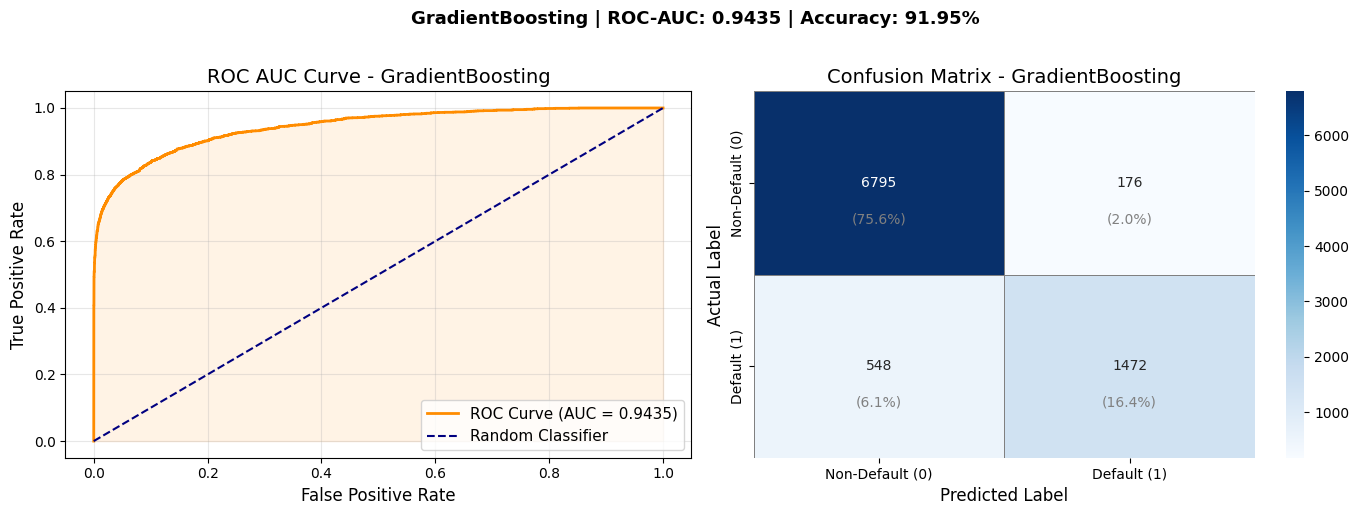

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# ============================================================
# 1. ROC AUC Curve
# ============================================================
fpr, tpr, _ = roc_curve(y_test, y_pred_proba_gbc)
roc_auc     = auc(fpr, tpr)

axes[0].plot(fpr, tpr, color='darkorange', lw=2,
             label=f'ROC Curve (AUC = {roc_auc:.4f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--',
             label='Random Classifier')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='darkorange')
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title('ROC AUC Curve - GradientBoosting', fontsize=14)
axes[0].legend(loc='lower right', fontsize=11)
axes[0].grid(True, alpha=0.3)

# ============================================================
# 2. Confusion Matrix
# ============================================================
cm = confusion_matrix(y_test, y_pred_gbc)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Default (0)', 'Default (1)'],
            yticklabels=['Non-Default (0)', 'Default (1)'],
            ax=axes[1], linewidths=0.5, linecolor='gray')

total = cm.sum()
for i in range(2):
    for j in range(2):
        axes[1].text(j + 0.5, i + 0.7,
                     f'({cm[i,j]/total*100:.1f}%)',
                     ha='center', va='center',
                     fontsize=10, color='gray')

axes[1].set_xlabel('Predicted Label', fontsize=12)
axes[1].set_ylabel('Actual Label', fontsize=12)
axes[1].set_title('Confusion Matrix - GradientBoosting', fontsize=14)

plt.suptitle(f'GradientBoosting | ROC-AUC: {roc_auc:.4f} | Accuracy: {(cm[0,0]+cm[1,1])/total*100:.2f}%',
             fontsize=13, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('gb_roc_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
final_metrics_data = [
    {
        'Model': 'Gradient Boosting (Tuned/Final)',
        'CV ROC-AUC Mean': 0.9377,
        'Test Accuracy': 0.9195,
        'Precision (Class 1)': 0.8900,
        'Recall (Class 1)': 0.7300,
        'F1-Score (Class 1)': 0.8000,
        'Test ROC-AUC': 0.9435
    },
    {
        'Model': 'Gradient Boosting (Base)',
        'CV ROC-AUC Mean': 0.9370,
        'Test Accuracy': 0.9191,
        'Precision (Class 1)': 0.8900,
        'Recall (Class 1)': 0.7300,
        'F1-Score (Class 1)': 0.8000,
        'Test ROC-AUC': 0.9429
    },
    {
        'Model': 'LightGBM (Tuned)',
        'CV ROC-AUC Mean': 0.9348, 
        'Test Accuracy': 0.9145,
        'Precision (Class 1)': 0.8900,
        'Recall (Class 1)': 0.7100,
        'F1-Score (Class 1)': 0.7900,
        'Test ROC-AUC': 0.9413
    },
    {
        'Model': 'LightGBM (Base)',
        'CV ROC-AUC Mean': 0.9341,
        'Test Accuracy': 0.9162,
        'Precision (Class 1)': 0.8900,
        'Recall (Class 1)': 0.7200,
        'F1-Score (Class 1)': 0.7900,
        'Test ROC-AUC': 0.9406
    },
    {
        'Model': 'XGBoost (Base)',
        'CV ROC-AUC Mean': 0.9297,
        'Test Accuracy': 0.9117,
        'Precision (Class 1)': 0.8500,
        'Recall (Class 1)': 0.7300,
        'F1-Score (Class 1)': 0.7900,
        'Test ROC-AUC': 0.9359
    },
    {
        'Model': 'Random Forest (Base)',
        'CV ROC-AUC Mean': 0.9179,
        'Test Accuracy': 0.8972,
        'Precision (Class 1)': 0.8000,
        'Recall (Class 1)': 0.7200,
        'F1-Score (Class 1)': 0.7600,
        'Test ROC-AUC': 0.9240
    },
    {
        'Model': 'Logistic Regression',
        'CV ROC-AUC Mean': 0.8547,
        'Test Accuracy': 0.7781,
        'Precision (Class 1)': 0.5000,
        'Recall (Class 1)': 0.7800,
        'F1-Score (Class 1)': 0.6100,
        'Test ROC-AUC': 0.8631
    }
]
df_summary = pd.DataFrame(final_metrics_data)
styled_summary = df_summary.style.background_gradient(
    cmap='Blues', 
    subset=['CV ROC-AUC Mean', 'Test Accuracy', 'Precision (Class 1)', 'Recall (Class 1)', 'F1-Score (Class 1)', 'Test ROC-AUC']
).format({
    'CV ROC-AUC Mean': '{:.4f}',
    'Test Accuracy': '{:.4f}',
    'Precision (Class 1)': '{:.4f}',
    'Recall (Class 1)': '{:.4f}',
    'F1-Score (Class 1)': '{:.4f}',
    'Test ROC-AUC': '{:.4f}'
})
styled_summary

,Model,CV ROC-AUC Mean,Test Accuracy,Precision (Class 1),Recall (Class 1),F1-Score (Class 1),Test ROC-AUC
0,Gradient Boosting (Tuned/Final),0.9377,0.9195,0.8900,0.7300,0.8000,0.9435
1,Gradient Boosting (Base),0.9370,0.9191,0.8900,0.7300,0.8000,0.9429
2,LightGBM (Tuned),0.9348,0.9145,0.8900,0.7100,0.7900,0.9413
3,LightGBM (Base),0.9341,0.9162,0.8900,0.7200,0.7900,0.9406
4,XGBoost (Base),0.9297,0.9117,0.8500,0.7300,0.7900,0.9359
5,Random Forest (Base),0.9179,0.8972,0.8000,0.7200,0.7600,0.9240
6,Logistic Regression,0.8547,0.7781,0.5000,0.7800,0.6100,0.8631
